/Users/mattfrichtl/opt/librecalphad/libreCalphad/models/segmented_regression.py:327: RuntimeWarning: invalid value encountered in divide
  res = 3 * R * (theta / T) ** 2 * np.exp(theta / T) / (np.exp(theta / T) - 1) ** 2


Optimized model parameters:
Theta_(D/E)=326.507529
beta_1=0.009700
beta_2=0.039610
tau=1754.698050
gamma=45.897440
RSE: 2.7742 J/mol/K


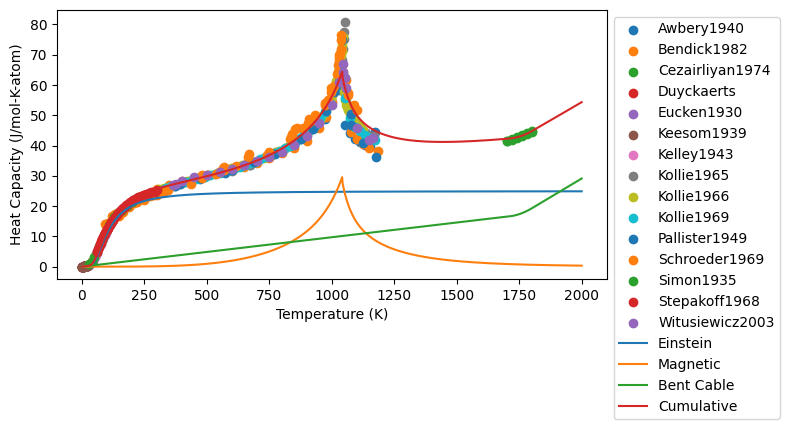

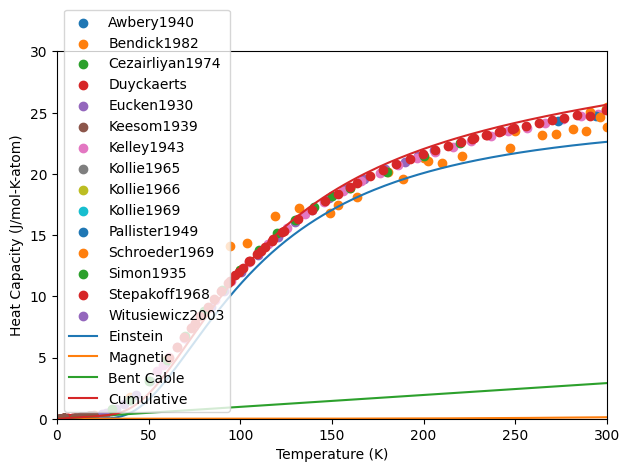

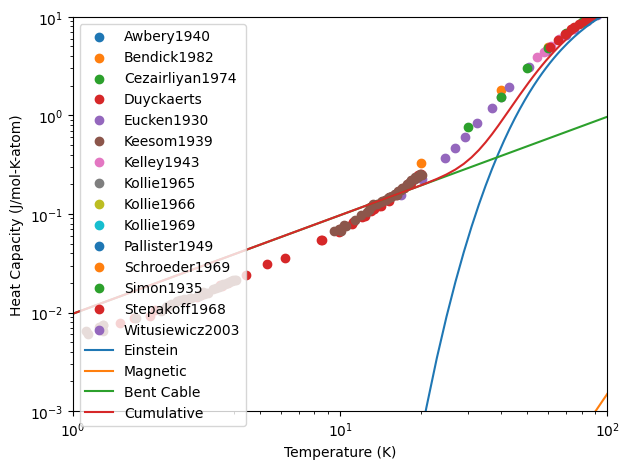

In [9]:
# Example of libreCalphad's heat capacity fitting routines and use of the segmented
# regression approach to model the Gibb's energy for creating custom reference
# states for pycalphad using ESPEI.

# Pycalphad has not implemented the Holzapfel approximation to the Debye model, so generating parameters
# for use with it should be done with the Einstein model for now.

from espei.datasets import load_datasets, recursive_glob
import json
import importlib.resources as impresources
from libreCalphad.models.segmented_regression import _bent_cable_Cp, _debye_Cp, _einstein_Cp, _holzapfel_debye_Cp, _xiong_Cp, fit_segmented_regression, get_segmented_regression_Cp, upsert_custom_refstate_json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pycalphad import variables as v
import yaml
from tinydb import where

R = 8.314472
# magnetic model constants
beta_Fe = 2.22  # magnetic moment per atom Fe
struct_fact_bcc = 0.37
Tc_Fe = 1043  # K, Curie temperature for Fe
theta_Fe = 309  # K, Einstein temperature from Chen & Sundman
param_gen_file = impresources.files("libreCalphad.databases") / "run_param_gen.yaml"
with open(param_gen_file, "r") as f:
    dataset_folder = yaml.safe_load(f)["system"]["datasets"]
datasets = load_datasets(recursive_glob(dataset_folder))
components = ["FE", "VA"]
phase = ["BCC_A2"]

query = (
    (where("phases") == phase)
    & (where("components") == components)
    & (where("output") == "CPM")
)
search_results = datasets.search(query)
model_dict = {"einstein": {"theta": [300, "fit"]}, "xiong": {"beta": [2.22, "fix"], "p": [0.37, "fix"], "Tc": [1043, "fix"]}, "bcm": {"beta_1": [0.01, "fit"], "beta_2": [0.04, "fit"], "tau": [1750, "fit"], "gamma": [50, "fit"]}}
min_fits = fit_segmented_regression(search_results, model_dict)
# initialize a dataframe for the model
df_model = pd.DataFrame()
df_model["temperature"] = np.linspace(1, 2000, num=1000)

print("Optimized model parameters:")
print(f"Theta_(D/E)={min_fits.x[0]:4f}")
print(f"beta_1={min_fits.x[1]:3f}")
print(f"beta_2={min_fits.x[2]:3f}")
print(f"tau={min_fits.x[3]:3f}")
print(f"gamma={min_fits.x[4]:3f}")
print(f"RSE: {min_fits.fun:.4f} J/mol/K")

# Save it to libreCalphad's custom refstate json file
refstate_file = "/Users/mattfrichtl/opt/libreCalphad-refstate/LCRefstates.json"
# Add the fitted refstate results
# Not passing the phase as a kwarg makes libreCalphad assume this is a stable phase Gibbs energy expression
upsert_custom_refstate_json(refstate_file, "FE", min_fits)

# Need to add the lattice stability for FE also, can directly write it to the json
with open(refstate_file, "r") as f:
    refstate_dict = json.load(f)
refstate_dict["FE-BCC_A2"] = "GHSERFE"
with open(refstate_file, "w") as f:
    json.dump(refstate_dict, f, indent=True)
# prepare arrays for plotting
# df_model["debye_model"] = _holzapfel_debye_Cp(df_model["temperature"], *min_fits.x[:1])
df_model["einstein_model"] = _einstein_Cp(df_model["temperature"], min_fits.x[0])
df_model["magnetic_model"] = _xiong_Cp(
    df_model["temperature"], beta_Fe, struct_fact_bcc, Tc_Fe
)
df_model["bent_cable_model"] = _bent_cable_Cp(df_model["temperature"], *min_fits.x[1:])
df_model["cumulative_model"] = df_model["einstein_model"] + df_model["magnetic_model"] + df_model["bent_cable_model"]

fig, ax = plt.subplots(figsize=(8,4))
for dataset in search_results:
    ax.scatter(dataset["conditions"]["T"], np.array(dataset["values"]).squeeze(), label=dataset["reference"])
# ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend(loc="upper left", bbox_to_anchor=(1,1))

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

# < 300 K
fig, ax = plt.subplots()
for dataset in search_results:
    ax.scatter(dataset["conditions"]["T"], np.array(dataset["values"]).squeeze(), label=dataset["reference"])
# ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlim((0, 300))
ax.set_xlabel("Temperature (K)")
ax.set_ylim((0, 30))
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

# Close to 0 K
fig, ax = plt.subplots()
for dataset in search_results:
    ax.scatter(dataset["conditions"]["T"], np.array(dataset["values"]).squeeze(), label=dataset["reference"])
# ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlim((1e0, 1e2))
ax.set_xscale("log")
ax.set_xlabel("Temperature (K)")
ax.set_ylim((1e-3, 1e1))
ax.set_yscale("log")
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

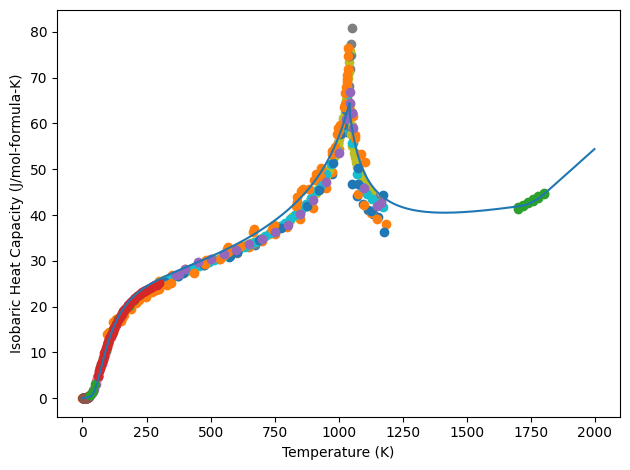

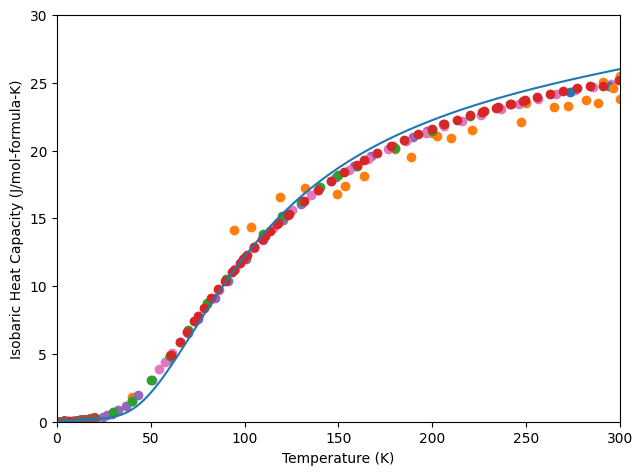

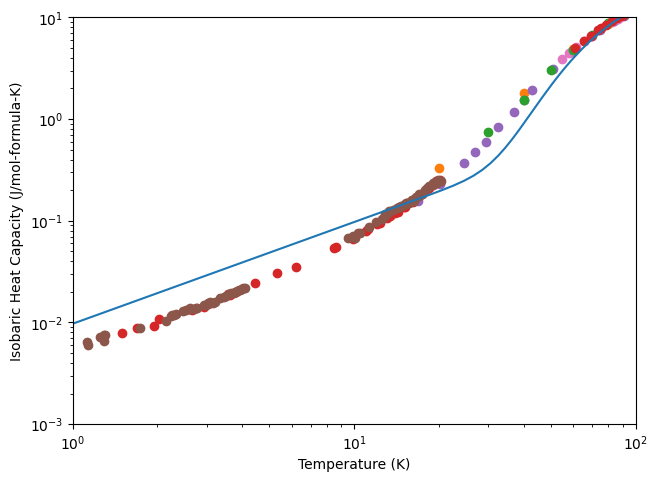

In [10]:
# Use these fits to generate a TDB file with ESPEI and check that pycalphad recreates the heat capacity

from espei.datasets import load_datasets, recursive_glob
import importlib.resources as impresources
from libreCalphad.databases.db_utils import load_database
import matplotlib.pyplot as plt
import numpy as np
from pycalphad import calculate
from tinydb import where
import yaml

dbf = load_database("LC-steels-thermo.tdb")
# Param gen file used to find datasets
param_gen_file = impresources.files("libreCalphad.databases") / "run_param_gen.yaml"
with open(param_gen_file, "r") as f:
    dataset_folder = yaml.safe_load(f)["system"]["datasets"]
datasets = load_datasets(recursive_glob(dataset_folder))
components = ["FE", "VA"]
phase = ["BCC_A2"]

query = (
    (where("phases") == phase)
    & (where("components") == components)
    & (where("output") == "CPM")
)
search_results = datasets.search(query)

fig, ax = plt.subplots()
cpm_res = calculate(
    dbf, components, "BCC_A2", T=(0.5, 2000, 2), P=101325, N=1, output="heat_capacity"
)
ax.plot(cpm_res.T, cpm_res.heat_capacity.squeeze())
for result in search_results:
    ax.scatter(
        result["conditions"]["T"],
        np.array(result["values"]).squeeze(),
        label=result["reference"],
    )
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Isobaric Heat Capacity (J/mol-formula-K)")
fig.tight_layout()

fig, ax = plt.subplots()
cpm_res = calculate(
    dbf, components, "BCC_A2", T=(0.5, 2000, 2), P=101325, N=1, output="heat_capacity"
)
ax.plot(cpm_res.T, cpm_res.heat_capacity.squeeze())
for result in search_results:
    ax.scatter(
        result["conditions"]["T"],
        np.array(result["values"]).squeeze(),
        label=result["reference"],
    )
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Isobaric Heat Capacity (J/mol-formula-K)")
fig.tight_layout()
ax.set_xlim((0, 300))
ax.set_ylim((0,30))

fig, ax = plt.subplots()
cpm_res = calculate(
    dbf, components, "BCC_A2", T=(0.5, 2000, 2), P=101325, N=1, output="heat_capacity"
)
ax.plot(cpm_res.T, cpm_res.heat_capacity.squeeze())
for result in search_results:
    ax.scatter(
        result["conditions"]["T"],
        np.array(result["values"]).squeeze(),
        label=result["reference"],
    )
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Isobaric Heat Capacity (J/mol-formula-K)")
fig.tight_layout()
ax.set_ylim((0, 30))
ax.set_xlim((1e0, 1e2))
ax.set_xscale("log")
ax.set_ylim((1e-3, 1e1))
ax.set_yscale("log")

__SER Energies__
H298: 13245.915285542374
S298: 37.28233807163296


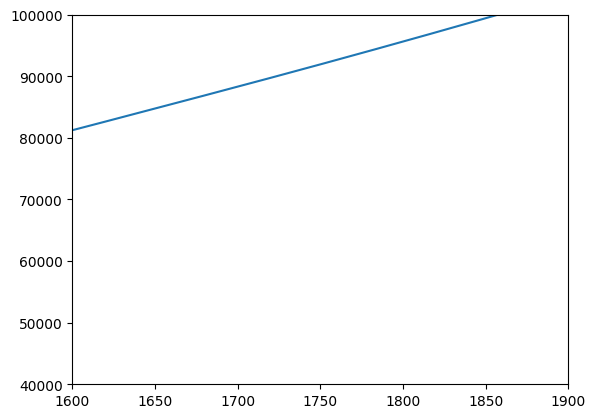

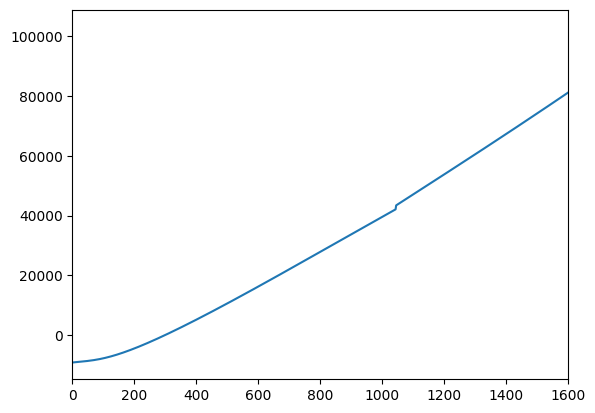

In [9]:
import espei
from libreCalphad.models.segmented_regression import calc_enthalpy, calc_entropy, calc_gibbs_energy, _xiong_enthalpy, _xiong_entropy, _bent_cable_enthalpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# magnetic model constants
beta_Fe = 2.22  # magnetic moment per atom Fe
struct_fact_bcc = 0.37
Tc_Fe = 1043  # K, Curie temperature for Fe
theta_Fe = 309  # K, Einstein temperature from Chen & Sundman
xiong_params = {"beta": beta_Fe, "p": struct_fact_bcc, "Tc": Tc_Fe}
H298 = calc_enthalpy(298.15, min_fits, xiong_params=xiong_params)
S298 = calc_entropy(298.15, min_fits, xiong_params=xiong_params)
df_model = pd.DataFrame()
df_model["temperature"] = np.linspace(1, 1900, num=1000)

enthalpy = calc_enthalpy(df_model["temperature"], min_fits, xiong_params=xiong_params)
# xiong_enthalpy = _xiong_enthalpy(df_model["temperature"], *list(xiong_params.values()))
# xiong_entropy = _xiong_entropy(df_model["temperature"], *list(xiong_params.values()))
# bc_enthalpy = _bent_cable_enthalpy(df_model["temperature"], *min_fits.x[1:])
entropy = calc_entropy(df_model["temperature"], min_fits, xiong_params=xiong_params)
gibbs = calc_gibbs_energy(df_model["temperature"], min_fits, xiong_params=xiong_params)

fig, ax = plt.subplots()
ax.plot(df_model["temperature"], enthalpy-H298)
ax.set_xlim((1600, 1900))
ax.set_ylim((40000,100000))


fig, ax = plt.subplots()
ax.plot(df_model["temperature"], enthalpy-H298)
ax.set_xlim((0, 1600))

print("__SER Energies__")
print(f"H298: {H298}")
print(f"S298: {S298}")

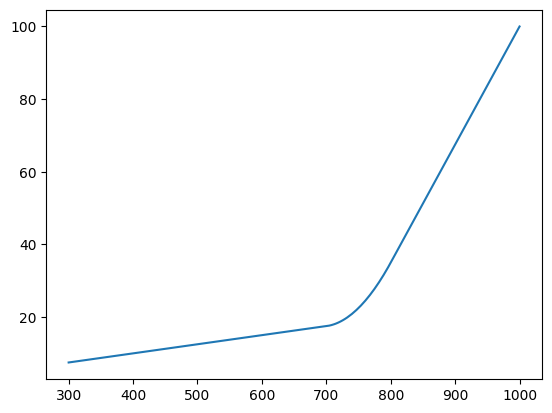

In [17]:
from libreCalphad.models import segmented_regression as sr
import numpy as np
import matplotlib.pyplot as plt

temp_arr = np.linspace(300, 1000, num=200)
cp_arr = sr._bent_cable_Cp(temp_arr, 0.025, 0.3, 750, 50)
plt.plot(temp_arr, cp_arr)

In [15]:
for cp in cp_arr:
    print(f"[{cp}],")
temp_arr

[7.5],
[7.5879396984924625],
[7.675879396984925],
[7.763819095477388],
[7.851758793969849],
[7.939698492462312],
[8.027638190954773],
[8.115577889447236],
[8.203517587939698],
[8.291457286432161],
[8.379396984924623],
[8.467336683417086],
[8.555276381909549],
[8.643216080402011],
[8.731155778894474],
[8.819095477386936],
[8.907035175879399],
[8.994974874371861],
[9.082914572864322],
[9.170854271356784],
[9.258793969849247],
[9.34673366834171],
[9.434673366834172],
[9.522613065326633],
[9.610552763819095],
[9.698492462311558],
[9.78643216080402],
[9.874371859296483],
[9.962311557788945],
[10.050251256281408],
[10.13819095477387],
[10.226130653266333],
[10.314070351758794],
[10.402010050251256],
[10.489949748743719],
[10.577889447236181],
[10.665829145728644],
[10.753768844221106],
[10.841708542713569],
[10.929648241206031],
[11.017587939698494],
[11.105527638190956],
[11.193467336683419],
[11.281407035175882],
[11.369346733668344],
[11.457286432160807],
[11.545226130653267],
[11.6331658

array([ 300.        ,  303.51758794,  307.03517588,  310.55276382,
        314.07035176,  317.5879397 ,  321.10552764,  324.62311558,
        328.14070352,  331.65829146,  335.1758794 ,  338.69346734,
        342.21105528,  345.72864322,  349.24623116,  352.7638191 ,
        356.28140704,  359.79899497,  363.31658291,  366.83417085,
        370.35175879,  373.86934673,  377.38693467,  380.90452261,
        384.42211055,  387.93969849,  391.45728643,  394.97487437,
        398.49246231,  402.01005025,  405.52763819,  409.04522613,
        412.56281407,  416.08040201,  419.59798995,  423.11557789,
        426.63316583,  430.15075377,  433.66834171,  437.18592965,
        440.70351759,  444.22110553,  447.73869347,  451.25628141,
        454.77386935,  458.29145729,  461.80904523,  465.32663317,
        468.84422111,  472.36180905,  475.87939698,  479.39698492,
        482.91457286,  486.4321608 ,  489.94974874,  493.46733668,
        496.98492462,  500.50251256,  504.0201005 ,  507.53768